<a href="https://colab.research.google.com/github/nyosef1108/multilayer-perceptron-from-scratch/blob/main/DEMO3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Training: Blue is continuous, Red is interrupted...
Epoch    0: Loss = 0.2298, Accuracy = 62.5%
Epoch  100: Loss = 0.0175, Accuracy = 97.7%
Epoch  200: Loss = 0.0163, Accuracy = 98.1%
Epoch  300: Loss = 0.0139, Accuracy = 98.2%
Epoch  400: Loss = 0.0137, Accuracy = 98.3%
Epoch  500: Loss = 0.0100, Accuracy = 98.8%
Epoch  599: Loss = 0.0105, Accuracy = 98.6%


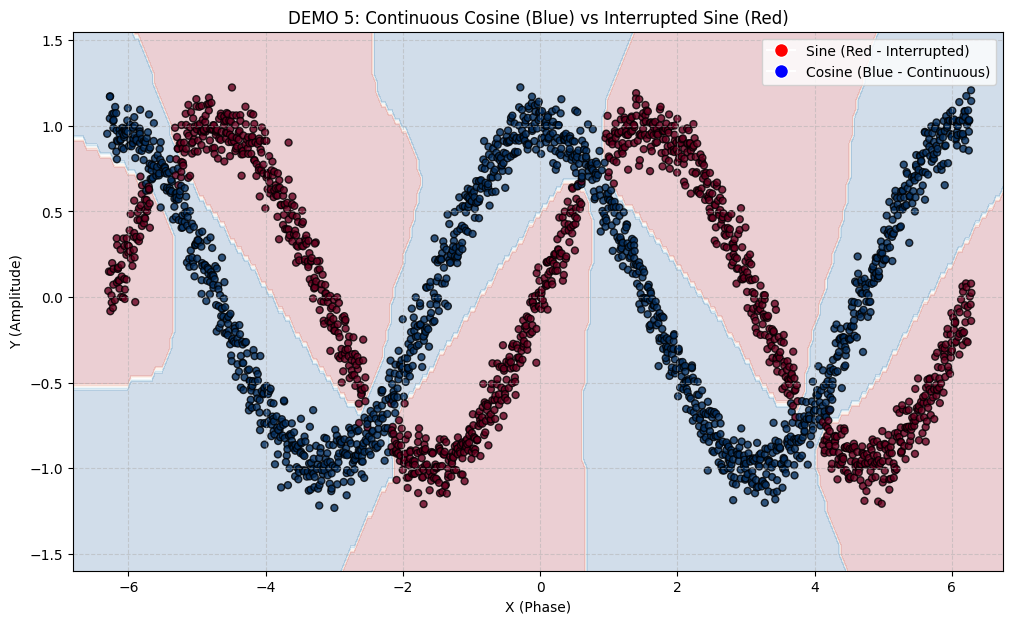

In [1]:

# DEMO 5: Continuous Cosine vs. Interrupted Sine
# Architecture: 2 Input -> 32 Hidden -> 32 Hidden -> 1 Output

!pip install --upgrade multilayer-perceptron-from-scratch

import numpy as np
import matplotlib.pyplot as plt
from multilayer_perceptron import Network
from matplotlib.lines import Line2D

def generate_hybrid_sin_cos(n_samples=3000, noise=0.1):
    X = []
    y = []

    t = np.linspace(-2 * np.pi, 2 * np.pi, n_samples // 2)

    for t_val in t:
        s_val = np.sin(t_val)
        c_val = np.cos(t_val)

        # מרחק בין הגרפים
        dist = abs(s_val - c_val)

        # 1. Cosine Wave (Class 1 - Blue) - רצוף תמיד
        x_c = t_val + np.random.randn() * 0.01
        y_c = c_val + np.random.randn() * noise
        X.append([x_c, y_c])
        y.append([1])

        # 2. Sine Wave (Class 0 - Red) - נקטע בנקודות חיתוך
        # הוא נוצר רק אם הוא רחוק מספיק מהקוסינוס כדי למנוע חפיפה
        if dist > 0.25:
            x_s = t_val + np.random.randn() * 0.01
            y_s = s_val + np.random.randn() * noise
            X.append([x_s, y_s])
            y.append([0])

    return np.array(X), np.array(y)

# --- Execution ---
X, y = generate_hybrid_sin_cos()
training_data = [(xi.reshape(2, 1), yi.reshape(1, 1)) for xi, yi in zip(X, y)]

# בניית הרשת
mlp = Network([2, 32, 32, 1])

print(f"Starting Training: Blue is continuous, Red is interrupted...")
mlp.SGD(training_data, epochs=600, learning_rate=0.08)

# --- Visualization ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = -1.6, 1.6
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

Z = []
for p in np.c_[xx.ravel(), yy.ravel()]:
    out, _, _ = mlp.feedforward(p.reshape(2, 1))
    Z.append(1 if out >= 0.5 else 0)

Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(12, 7))
plt.contourf(xx, yy, Z, cmap='RdBu', alpha=0.2)

# פיזור הנקודות
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='RdBu', edgecolors='k', s=25, alpha=0.8)

plt.title("DEMO 5: Continuous Cosine (Blue) vs Interrupted Sine (Red)")
plt.xlabel("X (Phase)")
plt.ylabel("Y (Amplitude)")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Sine (Red - Interrupted)', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cosine (Blue - Continuous)', markerfacecolor='blue', markersize=10)
]
plt.legend(handles=legend_elements)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()